In [1]:
import os

os.environ["TF_ENABLE_ONEDNN_OPTS"] = "2"

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten
from tensorflow.keras.datasets import mnist
from tensorflow.keras.utils import to_categorical
import matplotlib.pyplot as plt


In [4]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten
from tensorflow.keras.datasets import mnist
from tensorflow.keras.utils import to_categorical
import matplotlib.pyplot as plt


class MLPDigitRecognizer:
    def __init__(self):
        self.model = None
        self.history = None

    def load_and_preprocess_data(self):
        # Load MNIST dataset
        (x_train, y_train), (x_test, y_test) = mnist.load_data()

        # Normalize pixel values
        x_train = x_train.astype('float32') / 255.0
        x_test = x_test.astype('float32') / 255.0

        # One-hot encode labels
        y_train = to_categorical(y_train, 10)
        y_test = to_categorical(y_test, 10)

        return x_train, y_train, x_test, y_test

    def build_model(self):
        self.model = Sequential([
            Flatten(input_shape=(28, 28)),
            Dense(256, activation='relu'),
            Dense(128, activation='relu'),
            Dense(64, activation='relu'),
            Dense(10, activation='softmax')
        ])

        self.model.compile(
            optimizer='adam',
            loss='categorical_crossentropy',
            metrics=['accuracy']
        )

    def train_model(self, x_train, y_train):
        self.history = self.model.fit(
            x_train,
            y_train,
            epochs=10,
            batch_size=128,
            validation_split=0.2
        )

    def evaluate_model(self, x_test, y_test):
        loss, accuracy = self.model.evaluate(x_test, y_test)
        print(f"Test Accuracy: {accuracy:.4f}")

    def plot_accuracy(self):
        plt.plot(self.history.history['accuracy'], label='Training Accuracy')
        plt.plot(self.history.history['val_accuracy'], label='Validation Accuracy')
        plt.xlabel('Epoch')
        plt.ylabel('Accuracy')
        plt.legend()
        plt.title('MLP Training Performance')
        plt.show()

    def visualize_samples(self, x_data, y_data):
     
        plt.figure(figsize=(10, 4))

        for i in range(10):
            plt.subplot(2, 5, i + 1)
            plt.imshow(x_data[i], cmap='gray')
            plt.title(f"Label: {y_data[i].argmax()}")
            plt.axis('off')

        plt.tight_layout()
        plt.show()



c:\ProgramData\anaconda3\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.9116 - loss: 0.3040 - val_accuracy: 0.9595 - val_loss: 0.1407
Epoch 2/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.9666 - loss: 0.1109 - val_accuracy: 0.9673 - val_loss: 0.1087
Epoch 3/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9779 - loss: 0.0735 - val_accuracy: 0.9712 - val_loss: 0.0979
Epoch 4/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.9835 - loss: 0.0518 - val_accuracy: 0.9761 - val_loss: 0.0850
Epoch 5/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.9884 - loss: 0.0383 - val_accuracy: 0.9737 - val_loss: 0.0916
Epoch 6/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9908 - loss: 0.0289 - val_accuracy: 0.9750 - val_loss: 0.0951
Epoch 7/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.9919 - loss: 0.0236 - val_accuracy: 0.9752 - val_loss: 0.0981
Epoch 8/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.9932 - loss: 0.0197 - val_accuracy: 0.

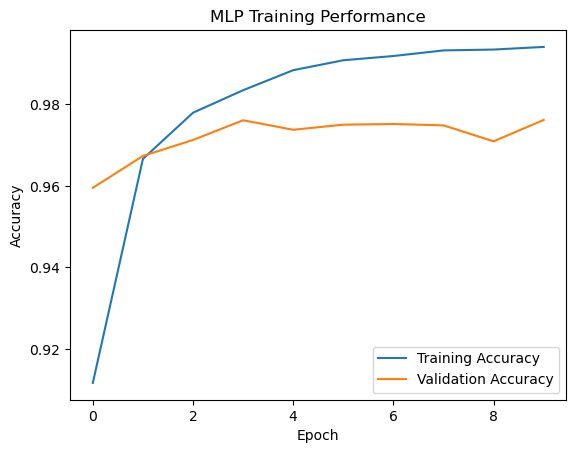

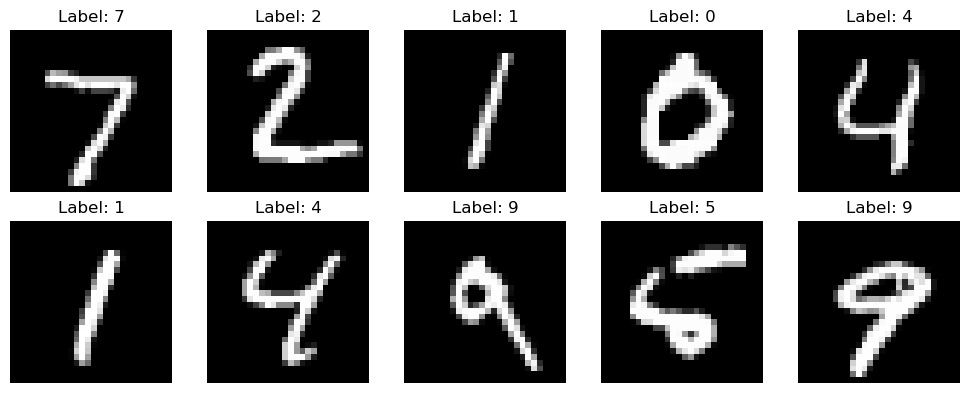

In [5]:
# -------- Main Program (Object Creation) --------
if __name__ == "__main__":
    mlp = MLPDigitRecognizer()          # Object creation
    x_train, y_train, x_test, y_test = mlp.load_and_preprocess_data()
    mlp.build_model()
    mlp.train_model(x_train, y_train)
    mlp.evaluate_model(x_test, y_test)
    mlp.plot_accuracy()
    mlp.visualize_samples(x_test, y_test)
